# Spotify RecSystem End to End (Sistema de Recomendação Spotify de Ponta a Ponta)
**[EN-US]**

Recommendation system, which recommends songs from Spotify. Created end-to-end, i.e. connecting and authorizing with the [Spotify API](https://developer.spotify.com/documentation/web-api), extracting data from the API, performing exploratory analysis, creating the model and producing the model.

**[PT-BR]**

Sistema de recomendação, que recomenda músicas do Spotify. Criado de ponta a ponta, ou seja, a conexão e autorização com a [Spotify API](https://developer.spotify.com/documentation/web-api), extração dos dados da API, realização da anaálise exploratória, criação do modelo e produção do modelo.

## Table of Contents
* [Packages](#Packages-(Pacotes))
* [Environment Variables](#Environment-Variables-(Variáveis-de-Ambiente))
* [Utils Functions](#Utils-Functions-(Funções-Utilitárias))
    * [Ingestion Functions](#Ingestion-Functions-(Funções-de-Ingestão))
        * [Request Authorization](#Request-Authorization-(Requisitando-a-Autorização))
        * [Playlist Extraction](#Playlist-Extraction-(Extração-da-Playlist))
        * [Track Features Extraction](#Track-Features-Extraction-(Extração-das-Features-da-Track))
        * [Playlist to DataFrame](#Playlist-to-DataFrame-(Playlist-para-DataFrame))
    * [Pre-Processing Functions](#Pre-Processing-Functions-(Funções-de-Pré-Processamento))
        * [Get User Dataset](#Get-User-Dataset-(Cria-o-Dataset-do-Usuário))
    * [Plot Functions](#Plot-Functions-(Funções-de-Gráficos))
        * [Get Pairs](#Get-Pairs-(Pega-os-Pares))
        * [Plot Histogram](#Plot-Histogram-(Gráfico-Histograma))
* [Playlist Data Extraction](#Playlist-Data-Extraction-(Extração-dos-Dados-da-Playlist))
    * [Request Authorization](#Request-Authorization-(Solicitar-Autorização))
    * [Playlists Definition](#Playlists-Definition-(Definição-das-Playlists))
    * [Data Extraction and Preparation](#Data-Extraction-and-Preparation-(Extração-e-Preparação-dos-Dados))
* [Exploratory Data Analysis](#Exploratory-Data-Analysis-(EDA))
* [Content-Based Filtering Model](#Content-Based-Filtering-Model)

## Packages (Pacotes)
**[EN-US]**
* [os](https://docs.python.org/3/library/os.html): built-in module, provides a portable way of using operating system dependent functionality.
* [requests](https://pypi.org/project/requests/): is a simple HTTP library, for making HTTP requests.
* [base64](https://docs.python.org/pt-br/3.7/library/base64.html): provides functions for encoding binary data to printable ASCII characters and decoding such encodings back to binary data.
* [dotenv](https://pypi.org/project/python-dotenv/): reads key-value pairs from a .env file and can set them as environment variables.
* [pandas](https://pandas.pydata.org/): is the main package for data manipulation.
* [numpy](www.numpy.org): is the main package for scientific computing.
* [matplotlib](http://matplotlib.org): is a library to plot graphs.

**[PT-BR]**
* [os](https://docs.python.org/3/library/os.html): módulo integrado, fornece uma maneira portátil de usar funcionalidades dependentes do sistema operacional.
* [requests](https://pypi.org/project/requests/): é uma biblioteca HTTP simples, para fazer solicitações HTTP.
* [base64](https://docs.python.org/pt-br/3.7/library/base64.html): fornece funções para codificar dados binários em caracteres ASCII imprimíveis e decodificar essas codificações de volta para dados binários.
* [dotenv](https://pypi.org/project/python-dotenv/): lê pares de chave-valor de um arquivo .env e pode defini-los como variáveis de ambiente.
* [pandas](https://pandas.pydata.org/): é o principal pacote para manipulação de dados.
* [numpy](www.numpy.org): é o principal pacote para computação científica.
* [matplotlib](http://matplotlib.org): é uma biblioteca para plotar gráficos.

In [16]:
import os
from requests import post, get
from base64 import b64encode
from dotenv import load_dotenv
load_dotenv() # access environment variables (acessa as variáveis de ambiente)

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 10) # set default size of plots (definindo o tamanho padrão dos plots)
import seaborn as sns
from random import randint

## Environment Variables (Variáveis de Ambiente)
**[EN-US]**

Setting the environment variables:
* `client_id`: the client ID generated after registering your application.
* `client_secret`: the client secret generated after registering your application.

**[PT-BR]**

Definindo as variáveis de ambiente:
* `client_id`: o cliente ID gerado após registrar seu aplicativo.
* `client_secret`: o client secret gerado após o registro do seu aplicativo.

In [19]:
client_id = os.environ['CLIENT_ID_SPOTIFY']
client_secret = os.environ['CLIENT_SECRET_SPOTIFY']

## Utils Functions (Funções Utilitárias)
**[EN-US]**

Various useful functions used in this system.

**[PT-BR]**

Várias funções utilitárias utilizadas nesse sistema.

### Ingestion Functions (Funções de Ingestão)
**[EN-US]**

The `request_auth` function to request authorization from Spotify, the `get_playlist` function to extract tracks from a playlist and the `track_features` function to extract the features of these tracks. After that, the `playlist_to_dataframe` function transforms the data into JSON for a pandas DataFrame.

**[PT-BR]**

Função `request_auth` para requisitar a autorização ao spotify, função `get_playlist` para extrair as tracks de uma playlist e a função `track_features` para extrair as features dessas tracks. Após isso, a função `playlist_to_dataframe` transforma os dados em JSON para um DataFrame pandas.

#### Request Authorization (Requisitando a Autorização)
**[EN-US]**

The first step is to send a POST request to the `/api/token` endpoint of the Spotify OAuth 2.0 Service. If everything goes well, you'll receive a response with a 200 OK status and the JSON data.

**[PT-BR]**

A primeira etapa é enviar uma requisição POST para o endpoint `/api/token` do serviço Spotify OAuth 2.0. Se tudo correr bem, você receberá uma resposta com o status 200 OK e os dados JSON.

In [24]:
def request_auth(client_id, client_secret):
    """
    [EN-US]
    The first step is to send a POST request to the /api/token endpoint of the Spotify OAuth 2.0 Service.
    If everything goes well, you'll receive a response with a 200 OK status and the JSON data.
    
    [PT-BR]
    A primeira etapa é enviar uma requisição POST para o endpoint /api/token do serviço Spotify OAuth 2.0.
    Se tudo correr bem, você receberá uma resposta com o status 200 OK e os dados JSON.
    
    Arguments:
    client_id -- The client ID generated after registering your application.
                 (O cliente ID gerado após registrar seu aplicativo.)
    client_secret -- the client secret generated after registering your application.
                     (O client secret gerado após o registro do seu aplicativo.)
    
    Returns:
    access_token -- An access token that can be provided in subsequent calls, for example to Spotify Web API services.
                    (Um token de acesso que pode ser fornecido em chamadas subsequentes, por exemplo, para serviços Spotify Web API.)
    token_type -- How the access token may be used: always "Bearer".
                  (Como o token de acesso pode ser utilizado: sempre “Bearer”.)
    token_expires -- The time period (in seconds) for which the access token is valid.
                     (O período de tempo (em segundos) durante o qual o token de acesso é válido.)
    """
    # Base 64 encoded string that contains the client ID and client secret key (String codificada em base 64 que contém o clinet ID e a client secret key)
    b64_encoded = b64encode(f'{client_id}:{client_secret}'.encode())
    auth_b64 = str(b64_encoded, 'utf-8')
    # Setting options for authorization (Definindo as opções para a autorização)
    base_url = 'https://accounts.spotify.com/api/token'    
    
    auth_options = {
        'url': base_url,
        'headers':{
            'Authorization': 'Basic ' + auth_b64,
            'content-type': 'application/x-www-form-urlencoded'
        },
        'form':{
            'grant_type': 'client_credentials'
        },
        'json': True
    }

    # Send a post request (Enviando a requisição post)
    request = post(url=auth_options['url'], headers=auth_options['headers'], data=auth_options['form'])
    # If the request status code is 200 (Caso o status code da requisição for 200)
    if request.status_code == 200:
        json_request = request.json()
        access_token = json_request['access_token']
        token_type = json_request['token_type']
        token_expires = json_request['expires_in']
        print('Acesso autorizado e dados extraídos!')
    else:
        print('Acesso não autorizado!')
        
    return access_token, token_type, token_expires

#### Playlist Extraction (Extração da Playlist)
**[EN-US]**

Get full details of the items of a playlist owned by a Spotify user.

**[PT-BR]**

Obtenha detalhes completos dos itens de uma playlist de um usuário do Spotify.

In [27]:
def get_playlist(playlist, token_type, access_token, offset=0, limit=100):
    """
    [EN-US]
    Get full details of the items of a playlist owned by a Spotify user.
    
    [PT-BR]
    Obtenha detalhes completos dos itens de uma playlist de propriedade de um usuário do Spotify.
    
    Arguments:
    playlist -- The Spotify URL of the playlist.
                (O URL do Spotify da playlist.)
    token_type -- How the access token may be used: always "Bearer".
                  (Como o token de acesso pode ser utilizado: sempre “Bearer”.)
    access_token -- An access token that can be provided in subsequent calls, for example to Spotify Web API services.
                    (Um token de acesso que pode ser fornecido em chamadas subsequentes, por exemplo, para serviços Spotify Web API.)
    offset -- The index of the first item to return. Default: 0 (the first item). Use with limit to get the next set of items.
              (O índice do primeiro item a ser retornado. Padrão: 0 (o primeiro item). Use com limit para obter o próximo conjunto de itens.)
    limit -- The maximum number of items to return. Default: 100. Minimum: 1. Maximum: 100.
             (O número máximo de itens a serem retornados. Padrão: 100. Mínimo: 1. Máximo: 100.)
    
    Returns:
    response.json() -- pages of tracks in JSON.
                       (páginas de tracks em JSON.)
    """
    # Turning the Spotify playlist URL into just the Playlist ID to send the get request (Transformando o Spotify URL da playlist apenas no Playlist ID para enviar a requisição get)
    playlist_id = playlist.split('/')[-1].split('?')[0]
    # Setting options for the request (Definindo as opções para a requisição)
    endpoint = f'https://api.spotify.com/v1/playlists/{playlist_id}/tracks?offset={str(offset)}&limit={str(limit)}'
    headers={
        'Authorization': token_type + ' ' + access_token
    }

    # Send a get request (Enviando a requisição get)
    response = get(url=endpoint, headers=headers)
    # If the request status code is not 200 (Caso o status code da requisição não seja 200)
    if response.status_code != 200:
        print('Error! Dados não extraídos.')

    return response.json()

#### Track Features Extraction (Extração das Features da Track)
**[EN-US]**

Get audio feature information for a single track identified by its unique Spotify ID.

**[PT-BR]**

Obtenha informações sobre features de áudio de uma única faixa identificada por seu ID exclusivo do Spotify.

In [30]:
def track_features(track_id, token_type, access_token):
    """
    [EN-US]
    Get audio feature information for a single track identified by its unique Spotify ID.
    
    [PT-BR]
    Obtenha informações sobre features de áudio de uma única faixa identificada por seu ID exclusivo do Spotify.
    
    Arguments:
    track_id -- The Spotify ID for the track.
                (O ID do Spotify para a track.)
    token_type -- How the access token may be used: always "Bearer".
                  (Como o token de acesso pode ser utilizado: sempre “Bearer”.)
    access_token -- An access token that can be provided in subsequent calls, for example to Spotify Web API services.
                    (Um token de acesso que pode ser fornecido em chamadas subsequentes, por exemplo, para serviços Spotify Web API.)
    
    Returns:
    response.json() -- Audio features for one track in JSON.
                       (Features de áudio para uma track em JSON.)
    """
    # Setting options for the request (Definindo as opções para a requisição)
    endpoint = f'https://api.spotify.com/v1/audio-features/{track_id}'
    headers={
        'Authorization': token_type + ' ' + access_token
    }
    
    # Send a get request (Enviando a requisição get)
    response = get(url=endpoint, headers=headers)
    # If the request status code is not 200 (Caso o status code da requisição não seja 200)
    if response.status_code != 200:
        print('Error! Dados não extraídos.')

    return response.json()

#### Playlist to DataFrame (Playlist para DataFrame)
**[EN-US]**

Input's a playlist URL and returns a pandas DataFrame.

**[PT-BR]**

A entrada é um URL de uma playlist e retorna um DataFrame do pandas.

In [27]:
def playlist_to_dataframe(playlist_endpoint, token_type, access_token, offset=0, limit=100, label=None):
    """
    [EN-US]
    Input's a playlist URL and returns a pandas DataFrame.
    
    [PT-BR]
    A entrada é um URL de uma playlist e retorna um DataFrame do pandas.
    
    Arguments:
    playlist_endpoint -- The Spotify URL of the playlist.
                         (O URL do Spotify da playlist.)
    token_type -- How the access token may be used: always "Bearer".
                  (Como o token de acesso pode ser utilizado: sempre “Bearer”.)
    access_token -- An access token that can be provided in subsequent calls, for example to Spotify Web API services.
                    (Um token de acesso que pode ser fornecido em chamadas subsequentes, por exemplo, para serviços Spotify Web API.)
    offset -- The index of the first item to return. Default: 0 (the first item). Use with limit to get the next set of items.
              (O índice do primeiro item a ser retornado. Padrão: 0 (o primeiro item). Use com limit para obter o próximo conjunto de itens.)
    limit -- The maximum number of items to return. Default: 100. Minimum: 1. Maximum: 100.
             (O número máximo de itens a serem retornados. Padrão: 100. Mínimo: 1. Máximo: 100.)
    label -- The label that the playlist will be classified by. Default: None. Label 1 for good playlist and 0 for bad playlist.
             (O label que a playlist será classificada. Padrão: None. Label 1 para playlist boa e 0 para playlist ruim.)
    
    Returns:
    df -- Pandas DataFrame with all tracks and the features of each track in the playlist.
          (DataFrame pandas com todas as tracks e as features de cada track da playlist.)
    """
    # Final list that will be transformed into DataFrame (Lista final que será transformada em DataFrame)
    examples = []
    # Tracks in JSON (Tracks em JSON)
    playlist = get_playlist(playlist=playlist_endpoint, token_type=token_type, access_token=access_token, offset=offset, limit=limit)
    
    # For loop through all playlist pages (Percorrendo todas as páginas da playlist)
    for page in range(offset, playlist['total'] + 1, limit):
        # Example size on page (Tamanho de exemplo na página)
        m = len(playlist['items'])
        # For loop through each example and adding the data to the final list (Percorrendo cada exemplo e adicionando os dados à lista final)
        for i in range(m):
            # Accessing each track (Acessando cada track)
            track = playlist['items'][i]['track']
            # Track features in JSON (Features da track em JSON)
            track_feature = track_features(track['id'], token_type, access_token)


            # Intermediate list for append each m example (Lista intermediária para adicionar cada exemplo m)
            example = [
                track['id'],
                track['name'],
                track['artists'][0]['name'],
                track['duration_ms'],
                track['popularity'],
                track_feature['danceability'],
                track_feature['energy'],
                track_feature['key'],
                track_feature['loudness'],
                track_feature['mode'],
                track_feature['speechiness'],
                track_feature['acousticness'],
                track_feature['instrumentalness'],
                track_feature['liveness'],
                track_feature['valence'],
                track_feature['tempo']
            ]

            # Adding to final list (Adicionando à lista final)
            examples.append(example)
        # If the page has more than 100 examples, you will read the next page
        # (Se a página tiver mais de 100 exemplos, lerá a próxima página)
        if m >= 100:
            # JSON tracks of the next offset (Tracks em JSON do próximo offset)
            playlist = get_playlist(playlist=playlist_endpoint, token_type=token_type, access_token=access_token, offset=page + limit, limit=limit)
    
    # DataFrame's features names (Nomes das features do DataFrame)
    features = ['id', 'name', 'artists', 'duration_ms', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
               'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
    # Transforming into DataFrame (Transformando em DataFrame)
    df = pd.DataFrame(examples, columns=features)
    
    # Setting the labels (Definindo os labels)
    if label == 0:
        df['y'] = 0
    elif label == 1:
        df['y'] = 1
    
    return df

### Pre-Processing Functions (Funções de Pré-Processamento)

#### Get User Dataset (Cria o Dataset do Usuário)
**[EN-US]**

Creates the user's dataset with the same number of examples as the dataset passed as input.

**[PT-BR]**

Cria o dataset do usuário com a mesma quantidade de exemplos que o dataset passado como input.

In [21]:
def get_user_dataset(item_df):
    """
    [EN-US]
    Receives a reference Dataset as input to create the user Dataset with the same number of examples.
    
    [PT-BR]
    Recebe um Dataset de referência como input para criar o Dataset do usuário com a mesma quantidade de exemplos.
    
    Argument:
    item_df -- Reference Dataset to create User Dataset
               (Dataset de referência para criar o Dataset do usuário).
    """
    # Deleting the feature that we will not use (Excluindo a feature que não iremos usar).
    item_df = item_df.drop(columns=['y'])
    # Creating the user matrix (Criando a matriz do usuário).
    user_df = np.zeros(item_df.shape)
    features = list(item_df.columns)
    # Setting 0 for the 'name' and 'artists' feature (Definindo 0 para a feature 'name' e 'artists').
    user_df[:, :2] = [0, 0]

    # Going through the matrix and assigning the average of each feature (Percorrendo a matriz e atribuindo a média de cada feature).
    for i, j in enumerate(features[2:]):
        user_df[:, i + 2] = np.mean(good_df[j])

    # Transforming the numpy array into a pandas DataFrame (Transformando o array numpy em um DataFrame pandas).
    user_df = pd.DataFrame(user_df, columns=features)
    return user_df

### Plot Functions (Funções de Gráficos)
**[EN-US]**

Utils functions for plots.

**[PT-BR]**

Funções utilitários para plots.

#### Get Pairs (Pega os Pares)
**[EN-US]**

Randomly returns 25 unique pairs of features.

**[PT-BR]**

Retorna aleatoriamente 25 pares únicos de features.

In [25]:
def get_pairs(df):
    """
    [EN-US]
    The input is a DataFrame and returns a list of unique pairs of features from that DataFrame.
    
    [PT-BR]
    A entrada é um DataFrame e retorna uma lista com pares únicos de features desse DataFrame.
    
    Argument:
    df -- DataFrame to randomly get 25 unique pairs of your features.
          (DataFrame para pegar aleatóriamente 25 pares únicos de suas features.)
    
    Returns:
    pairs -- List with unique pairs of DataFrame features.
             (Lista com pares únicos de features do DataFrame.)
    """
    # Empty list to store tuples with pairs (Lista vazia para armazenar os as tuplas com os pares).
    pairs = []

    for i in range(25):
        # Selecting the first feature (Selecionando a primeira feature).
        x = df.columns[randint(0,12)]
        # Selecting the second feature (Selecionando a segunda feature).
        y = df.columns[randint(0,12)]
        # Loop to not select the 2nd feature repeated or equal to the first feature
        # (Loop para não selecionar a 2 feature repetida ou igual a primeira feature).
        while x == y or (x, y) in pairs or (y, x) in pairs:
            y = df.columns[randint(0,12)]
        pairs.append((x, y))
    
    return pairs

#### Plot Histogram (Gráfico Histograma)
**[EN-US]**

Returns a histogram comparing a feature between 2 datasets.

**[PT-BR]**

Retorna um histograma comparando uma feature entre 2 datasets.

In [29]:
def plot_hist_vs(feature, dataset_1, dataset_2):
    """
    [EN-US]
    The input is 2 Datasets and 1 feature to plot a histogram and compare the distribution of the 2 Datasets.
    
    [PT-BR]
    A entrada são 2 Datasets e 1 feature para plotar um histograma e comparar a distribuição dos 2 Datasets.
    
    Arguments:
    feature -- The feature to create the plot (A feature para criar o plot).
    dataset_1 -- The first Dataset to be plotted
                 (O primeiro Dataset para ser plotado).
    dataset_2 -- The second Dataset to be plotted
                 (O segundo Dataset para ser plotado).
    """
    plt.hist(dataset_1[feature], bins=100, color='b', label='Good')
    plt.hist(dataset_2[feature], bins=100, color='r', alpha=0.5, label='Bad')    
    plt.title(f'Good vs. Bad {feature.capitalize()}')
    plt.legend(loc='best')
    plt.show()

## Playlist Data Extraction (Extração dos Dados da Playlist)

### Request Authorization (Solicitar Autorização)

In [47]:
access_token, token_type, token_expires = request_auth(client_id=client_id, client_secret=client_secret)

Acesso autorizado e dados extraídos!


### Playlists Definition (Definição das Playlists)

In [8]:
good_songs = 'https://open.spotify.com/playlist/6DI0NiX9bE3fIF6cEoI2zL?si=ef8a610d53f64627'
bad_songs = 'https://open.spotify.com/playlist/6IBody2iNg5TgmAeYiHYpW?si=xsEvNjbbQYqt0rs9wP3yOg'

### Data Extraction and Preparation (Extração e Preparação dos Dados)

In [9]:
df_good = playlist_to_dataframe(good_songs, token_type, access_token, offset=0, limit=100, label=1)
df_bad = playlist_to_dataframe(bad_songs, token_type, access_token, offset=0, limit=100, label=0)
df_good.head()

,id,name,artists,duration_ms,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,y
0,1XNdu4czbxZ9tdVOhDtI4M,Cheia de Manias,Raça Negra,211000,51,0.707,0.614,7,-9.377,0,0.0580,0.198,0.000000,0.1770,0.957,156.473,1
1,1SaeGiWS1LQhfRc6ObQfvq,Que Se Chama Amor,Só Pra Contrariar,245200,0,0.647,0.528,7,-12.739,1,0.0409,0.411,0.000000,0.0481,0.621,136.118,1
2,6jBZxE0VZpmgZud4L5lo0u,Paparico,Molejo,220426,53,0.738,0.850,9,-7.278,1,0.0756,0.530,0.000000,0.2130,0.967,88.799,1
3,43uHeQc9kdMzFAbxCTcgiI,Telegrama,Exaltasamba,219866,54,0.517,0.516,11,-12.441,1,0.0342,0.443,0.000004,0.2360,0.601,151.060,1
4,4tILvSk9XcdCBzjyzhsuze,É Tarde Demais,Raça Negra,214693,50,0.615,0.403,4,-11.648,1,0.0282,0.425,0.000004,0.3210,0.454,136.377,1


In [42]:
df_bad.drop(columns=['name'])

,id,artists,duration_ms,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,y,duration_min
0,76oTcfNSAGS1cmzVTjof5e,MC Levin,168250,28,0.684,0.443,5,-6.753,0,0.3230,0.49400,0.003050,0.0288,0.629,88.506,0,2.804167
1,2kWowyDGD9yOL0WQzni20m,Mc IG,162046,0,0.802,0.520,0,-6.973,1,0.2530,0.44700,0.000000,0.0942,0.956,160.054,0,2.700767
2,142YjJNOuXjzeSDnB1ujw1,MC Levin,178173,58,0.947,0.556,7,-4.536,1,0.0736,0.27700,0.000005,0.2080,0.426,130.046,0,2.969550
3,0jlLqG8aydyDjZkJ0ShmPg,MC Menor Mr,184000,0,0.719,0.565,3,-5.924,1,0.2120,0.30900,0.000000,0.0768,0.643,82.732,0,3.066667
4,5PNJXjGx8PAFooqCRuTUIv,Mc Magal,190907,49,0.552,0.491,1,-5.261,1,0.3120,0.07890,0.000000,0.0471,0.765,86.041,0,3.181783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,2QKYsuDCtjbzoBdaan7Ybd,MC Gomes,173671,0,0.911,0.583,6,-4.517,0,0.1690,0.13900,0.000266,0.1700,0.593,131.008,0,2.894517
366,4sDFmfir0mmHFeVgbg2WgR,MC Neguinho do Kaxeta,138181,23,0.860,0.441,4,-8.664,1,0.0710,0.39300,0.000000,0.0647,0.566,132.188,0,2.303017
367,3Z0kqYFQYF7KLli5gAMkf3,MC Cainho,189857,2,0.718,0.539,1,-3.643,1,0.2760,0.60000,0.000828,0.1560,0.619,130.088,0,3.164283
368,4he5PH2421GeKAJ5a4Ftqu,MC Maneirinho,123600,23,0.494,0.703,2,-6.214,1,0.4180,0.00664,0.000000,0.1180,0.851,183.801,0,2.060000


In [43]:
df_good['duration_min'] = df_good['duration_ms'] / 60000
df_good.head()

,id,name,artists,duration_ms,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,y,duration_min
0,1XNdu4czbxZ9tdVOhDtI4M,Cheia de Manias,Raça Negra,211000,51,0.707,0.614,7,-9.377,0,0.0580,0.198,0.000000,0.1770,0.957,156.473,1,3.516667
1,1SaeGiWS1LQhfRc6ObQfvq,Que Se Chama Amor,Só Pra Contrariar,245200,0,0.647,0.528,7,-12.739,1,0.0409,0.411,0.000000,0.0481,0.621,136.118,1,4.086667
2,6jBZxE0VZpmgZud4L5lo0u,Paparico,Molejo,220426,53,0.738,0.850,9,-7.278,1,0.0756,0.530,0.000000,0.2130,0.967,88.799,1,3.673767
3,43uHeQc9kdMzFAbxCTcgiI,Telegrama,Exaltasamba,219866,54,0.517,0.516,11,-12.441,1,0.0342,0.443,0.000004,0.2360,0.601,151.060,1,3.664433
4,4tILvSk9XcdCBzjyzhsuze,É Tarde Demais,Raça Negra,214693,50,0.615,0.403,4,-11.648,1,0.0282,0.425,0.000004,0.3210,0.454,136.377,1,3.578217


In [73]:
df_bad['duration_min'] = df_bad['duration_ms'] / 60000

In [25]:
#df_good.to_csv('./data/df_good.csv', index=False)
#df_bad.to_csv('./data/df_bad.csv', index=False)

## Exploratory Data Analysis (EDA)
**[EN-US]**

Exploratory Data Analysis.

Input $X$ features:
* `id`: the Spotify ID for the track.
* `name`: the name of the track.
* `artists`: the principal artist who performed the track.
* `duration_ms`: the track length in milliseconds.
* `popularity`: a measure from 0 to 100 describing the popularity of the track.
* `danceability`: a measure from 0.0 to 1.0 describing how suitable a track is for dancing.
* `energy`: a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity.
* `key`: the key the track is in. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1.
* `loudness`: the overall loudness of a track in decibels (dB). Values typically range between -60 and 0 db.
* `mode`: indicates the modality, major "1" or minor "0", of a track.
* `speechiness`: a measure from 0.0 to 1.0 detecting the presence of spoken words in a track.
* `acousticness`: a confidence measure from 0.0 to 1.0 of whether the track is acoustic.
* `instrumentalness`: a measure from 0.0 to 1.0 predicting whether a track contains no vocals.
* `liveness`: a mearure from 0.0 to 1.0 detecting the presence of an audience in the recording.
* `valence`: a measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track.
* `tempo`: the overall estimated tempo of a track in beats per minute (BPM).
* `y`: the track's label, 1 for good and 0 otherwise.
* `duration_min`: the track length in minutes.

**[PT-BR]**

Análise de Dados Exploratória.

Variáveis do input $X$:
* `id`: o ID do Spotify para a track.
* `name`: o nome da track.
* `artists`: (o artista principal que executaram a faixa.
* `duration_ms`: a duração da track em milissegundos.
* `popularity`: uma medida de 0 a 100 que descreve a popularidade da track.
* `danceability`: uma medida de 0,0 a 1,0 que descreve o quão adequada uma track é para dançar.
* `energy`: uma medida de 0,0 a 1,0 e representa uma medida perceptiva de intensidade e atividade.
* `key`: o tom em que a track está. 0 = C, 1 = C♯/D♭, 2 = D e assim por diante. Se nenhuma chave for detectada, o valor será -1.
* `loudness`: o volume geral de uma track em decibéis (dB). Os valores normalmente variam entre -60 e 0 db.
* `mode`: indica a modalidade, maior "1" ou menor "0", de uma track.
* `speechiness`: medida de 0,0 a 1,0 que detecta a presença de palavras faladas em uma track.
* `acousticness`: uma medida de confiança de 0,0 a 1,0 para saber se a track é acústica.
* `instrumentalness`: uma medida de 0,0 a 1,0 que prevê se uma track não contém vocais.
* `liveness`: detecta a presença de um público na gravação.
* `valence`: uma medida de 0,0 a 1,0 que descreve a positividade musical transmitida por uma track.
* `tempo`: o andamento geral estimado de uma track em batidas por minuto (BPM).
* `y`: o label da track, 1 para bom e 0 para caso contrário.
* `duration_min`: a duração da track em minutos.

In [49]:
good = pd.read_csv('./data/df_good.csv').drop(columns=['id'])
bad = pd.read_csv('./data/df_bad.csv').drop(columns=['name', 'id'])
good.head()

,name,artists,duration_ms,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,y,duration_min
0,Cheia de Manias,Raça Negra,211000,51,0.707,0.614,7,-9.377,0,0.0580,0.198,0.000000,0.1770,0.957,156.473,1,3.516667
1,Que Se Chama Amor,Só Pra Contrariar,245200,0,0.647,0.528,7,-12.739,1,0.0409,0.411,0.000000,0.0481,0.621,136.118,1,4.086667
2,Paparico,Molejo,220426,53,0.738,0.850,9,-7.278,1,0.0756,0.530,0.000000,0.2130,0.967,88.799,1,3.673767
3,Telegrama,Exaltasamba,219866,54,0.517,0.516,11,-12.441,1,0.0342,0.443,0.000004,0.2360,0.601,151.060,1,3.664433
4,É Tarde Demais,Raça Negra,214693,50,0.615,0.403,4,-11.648,1,0.0282,0.425,0.000004,0.3210,0.454,136.377,1,3.578217


In [51]:
print(f'Total de tracks na playlist good: {good.shape[0]}, total de tracks na playlist bad: {bad.shape[0]}')

Total de tracks na playlist good: 614, total de tracks na playlist bad: 370


In [53]:
X = pd.concat([good, bad], axis=0, ignore_index=True)
X.head()

,name,artists,duration_ms,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,y,duration_min
0,Cheia de Manias,Raça Negra,211000,51,0.707,0.614,7,-9.377,0,0.0580,0.198,0.000000,0.1770,0.957,156.473,1,3.516667
1,Que Se Chama Amor,Só Pra Contrariar,245200,0,0.647,0.528,7,-12.739,1,0.0409,0.411,0.000000,0.0481,0.621,136.118,1,4.086667
2,Paparico,Molejo,220426,53,0.738,0.850,9,-7.278,1,0.0756,0.530,0.000000,0.2130,0.967,88.799,1,3.673767
3,Telegrama,Exaltasamba,219866,54,0.517,0.516,11,-12.441,1,0.0342,0.443,0.000004,0.2360,0.601,151.060,1,3.664433
4,É Tarde Demais,Raça Negra,214693,50,0.615,0.403,4,-11.648,1,0.0282,0.425,0.000004,0.3210,0.454,136.377,1,3.578217


In [55]:
print(f'Total de tracks no dataset dos itens: {X.shape[0]}')

Total de tracks no dataset dos itens: 984


In [57]:
X['y'].value_counts()

y
1    614
0    370
Name: count, dtype: int64

In [61]:
good_df, bad_df = X[X['y'] == 1].copy(), X[X['y'] == 0].copy()
good_df.head()

,name,artists,duration_ms,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,y,duration_min
0,Cheia de Manias,Raça Negra,211000,51,0.707,0.614,7,-9.377,0,0.0580,0.198,0.000000,0.1770,0.957,156.473,1,3.516667
1,Que Se Chama Amor,Só Pra Contrariar,245200,0,0.647,0.528,7,-12.739,1,0.0409,0.411,0.000000,0.0481,0.621,136.118,1,4.086667
2,Paparico,Molejo,220426,53,0.738,0.850,9,-7.278,1,0.0756,0.530,0.000000,0.2130,0.967,88.799,1,3.673767
3,Telegrama,Exaltasamba,219866,54,0.517,0.516,11,-12.441,1,0.0342,0.443,0.000004,0.2360,0.601,151.060,1,3.664433
4,É Tarde Demais,Raça Negra,214693,50,0.615,0.403,4,-11.648,1,0.0282,0.425,0.000004,0.3210,0.454,136.377,1,3.578217


In [63]:
user = get_user_dataset(X)

assert X.drop(columns=['y']).shape == user.shape, 'Dimensão dos datasets incorretas.'
user.head()

,name,artists,duration_ms,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
0,0.0,0.0,233741.218241,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687
1,0.0,0.0,233741.218241,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687
2,0.0,0.0,233741.218241,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687
3,0.0,0.0,233741.218241,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687
4,0.0,0.0,233741.218241,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687


In [65]:
print(f'Tamanho do dataset do usuário: {user.shape[0]}')

Tamanho do dataset do usuário: 984


In [67]:
user_df = user.iloc[:, 3:].copy()
user_df

,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
0,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687
1,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687
2,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687
3,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687
4,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687
...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687
980,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687
981,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687
982,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687


In [69]:
good_df['artists'].value_counts().sort_values(ascending=False).head(10)

artists
Iron Maiden           40
System Of A Down      34
Alanis Morissette     14
Mamonas Assassinas    13
Phoenix               12
ANGRA                 11
The Kooks              8
The Offspring          8
Kings of Leon          7
Måneskin               7
Name: count, dtype: int64

In [71]:
good_df = good_df.drop_duplicates()
good_df[good_df.duplicated()]

,name,artists,duration_ms,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,y,duration_min


In [73]:
bad_df[bad_df.duplicated()]

,name,artists,duration_ms,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,y,duration_min
762,NaN,MC Menor Mr,210720,42,0.918,0.895,10,-2.381,0,0.318,0.172,0.000000,0.0829,0.910,104.919,0,3.512
764,NaN,Mc PP da VS,171000,0,0.887,0.344,0,-13.813,0,0.443,0.188,0.000002,0.1780,0.827,80.000,0,2.850


In [75]:
bad_df = bad_df.drop_duplicates()
bad_df[bad_df.duplicated()]

,name,artists,duration_ms,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,y,duration_min


In [77]:
good_df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration_ms,614.0,233741.218241,73043.475785,42466.000000,190502.750000,222993.000000,266190.000000,818693.000000
popularity,614.0,40.916938,28.302916,0.000000,3.000000,50.000000,64.000000,87.000000
danceability,614.0,0.508020,0.148325,0.144000,0.392000,0.509500,0.613500,0.893000
energy,614.0,0.722435,0.232200,0.029800,0.577000,0.799500,0.911000,0.997000
key,614.0,5.382736,3.475164,0.000000,2.000000,5.000000,9.000000,11.000000
loudness,614.0,-6.664011,3.022693,-20.232000,-8.475250,-6.024000,-4.491250,-1.359000
mode,614.0,0.672638,0.469633,0.000000,0.000000,1.000000,1.000000,1.000000
speechiness,614.0,0.066790,0.055165,0.024100,0.033900,0.047500,0.074175,0.485000
acousticness,614.0,0.200190,0.286902,0.000007,0.003182,0.037800,0.304250,0.982000
instrumentalness,614.0,0.032501,0.132386,0.000000,0.000000,0.000038,0.002658,0.962000


In [79]:
good_df.info(), bad_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              614 non-null    object 
 1   artists           614 non-null    object 
 2   duration_ms       614 non-null    int64  
 3   popularity        614 non-null    int64  
 4   danceability      614 non-null    float64
 5   energy            614 non-null    float64
 6   key               614 non-null    int64  
 7   loudness          614 non-null    float64
 8   mode              614 non-null    int64  
 9   speechiness       614 non-null    float64
 10  acousticness      614 non-null    float64
 11  instrumentalness  614 non-null    float64
 12  liveness          614 non-null    float64
 13  valence           614 non-null    float64
 14  tempo             614 non-null    float64
 15  y                 614 non-null    int64  
 16  duration_min      614 non-null    float64
dtypes:

(None, None)

In [95]:
good_df.isnull().sum(), bad_df.drop(columns=['name']).isnull().sum()

(name                0
 artists             0
 duration_ms         0
 popularity          0
 danceability        0
 energy              0
 key                 0
 loudness            0
 mode                0
 speechiness         0
 acousticness        0
 instrumentalness    0
 liveness            0
 valence             0
 tempo               0
 y                   0
 duration_min        0
 dtype: int64,
 artists             0
 duration_ms         0
 popularity          0
 danceability        0
 energy              0
 key                 0
 loudness            0
 mode                0
 speechiness         0
 acousticness        0
 instrumentalness    0
 liveness            0
 valence             0
 tempo               0
 y                   0
 duration_min        0
 dtype: int64)

In [83]:
print(f'Duração média: {np.mean(good_df["duration_min"]):.2f}min\nPopularidade média: {np.mean(good_df["popularity"]):.1f}')

Duração média: 3.90min
Popularidade média: 40.9


In [85]:
bad_df['artists'].value_counts().sort_values(ascending=False).head(10)

artists
Mc 7 Belo                 16
Mc Brisola                 7
Mc Magrinho                7
Mc Kitinho                 6
MC Vitinho Avassalador     6
Mc Neguinho do ITR         6
MC Gudan                   5
Mc Talibã                  5
Mc Gw                      5
MC Rafa 22                 5
Name: count, dtype: int64

In [87]:
print(f'Duração média: {np.mean(bad_df["duration_min"]):.2f}min\nPopularidade média: {np.mean(bad_df["popularity"]):.1f}')

Duração média: 2.90min
Popularidade média: 9.3


In [89]:
X_num = X.drop(columns=['name', 'artists', 'y', 'duration_ms']).copy()

In [91]:
X_num

,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
0,51,0.707,0.614,7,-9.377,0,0.0580,0.19800,0.000000,0.1770,0.957,156.473,3.516667
1,0,0.647,0.528,7,-12.739,1,0.0409,0.41100,0.000000,0.0481,0.621,136.118,4.086667
2,53,0.738,0.850,9,-7.278,1,0.0756,0.53000,0.000000,0.2130,0.967,88.799,3.673767
3,54,0.517,0.516,11,-12.441,1,0.0342,0.44300,0.000004,0.2360,0.601,151.060,3.664433
4,50,0.615,0.403,4,-11.648,1,0.0282,0.42500,0.000004,0.3210,0.454,136.377,3.578217
...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,0,0.911,0.583,6,-4.517,0,0.1690,0.13900,0.000266,0.1700,0.593,131.008,2.894517
980,23,0.860,0.441,4,-8.664,1,0.0710,0.39300,0.000000,0.0647,0.566,132.188,2.303017
981,2,0.718,0.539,1,-3.643,1,0.2760,0.60000,0.000828,0.1560,0.619,130.088,3.164283
982,23,0.494,0.703,2,-6.214,1,0.4180,0.00664,0.000000,0.1180,0.851,183.801,2.060000


In [93]:
items = X.iloc[:, :2].copy()
items

,name,artists
0,Cheia de Manias,Raça Negra
1,Que Se Chama Amor,Só Pra Contrariar
2,Paparico,Molejo
3,Telegrama,Exaltasamba
4,É Tarde Demais,Raça Negra
...,...,...
979,NaN,MC Gomes
980,NaN,MC Neguinho do Kaxeta
981,NaN,MC Cainho
982,NaN,MC Maneirinho


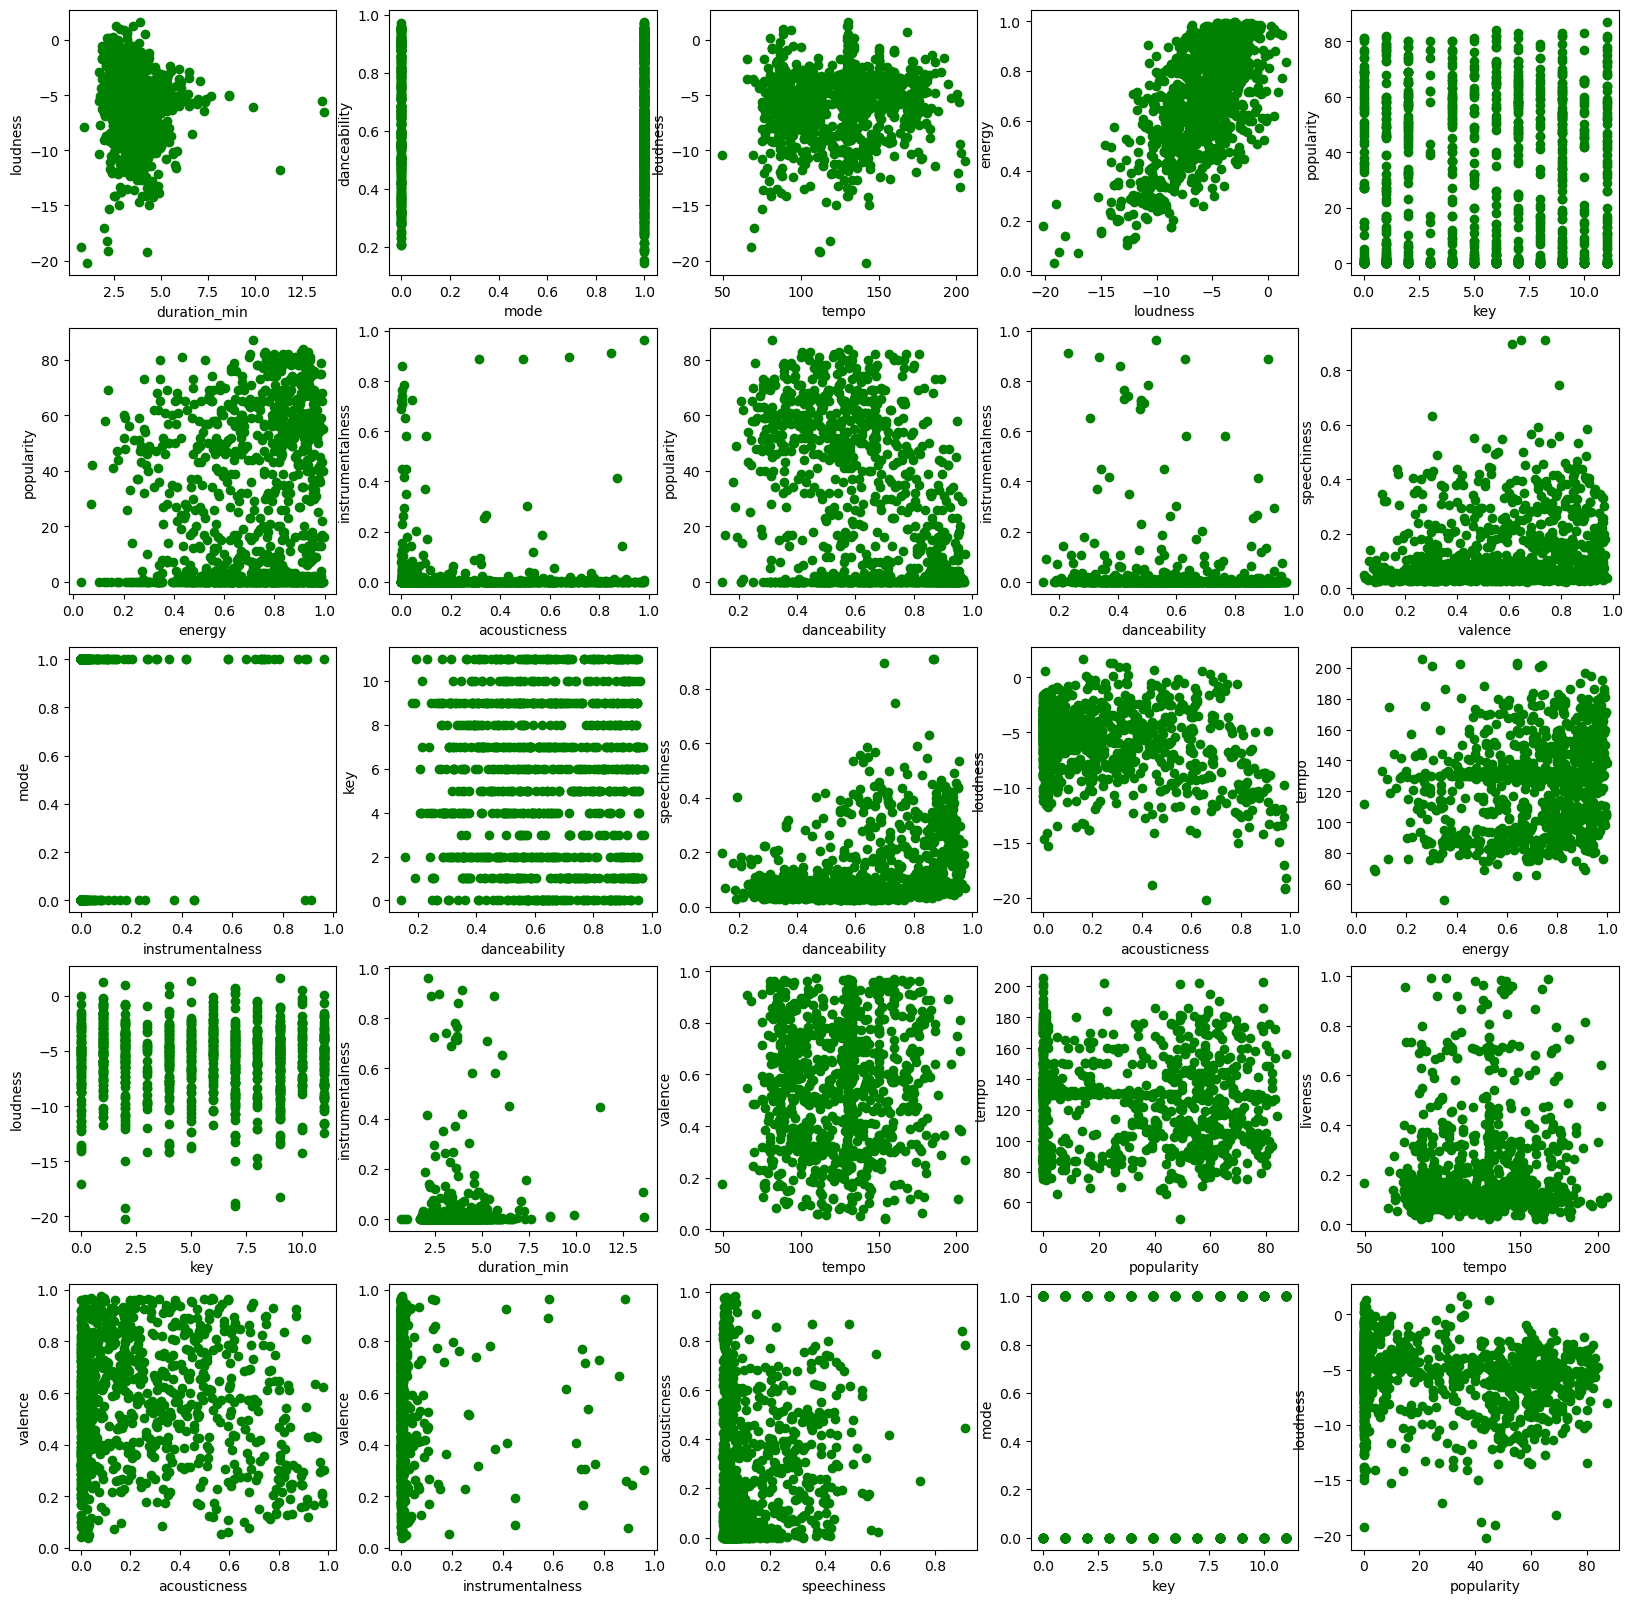

In [221]:
pairs = get_pairs(X_num)

fig, axs = plt.subplots(5, 5, figsize=(20, 20))
i = 0
for rows in axs:
    for ax in rows:
        ax.scatter(X_num[pairs[i][0]], X_num[pairs[i][1]], c='g')
        ax.set_xlabel(pairs[i][0])
        ax.set_ylabel(pairs[i][1])
        i+=1

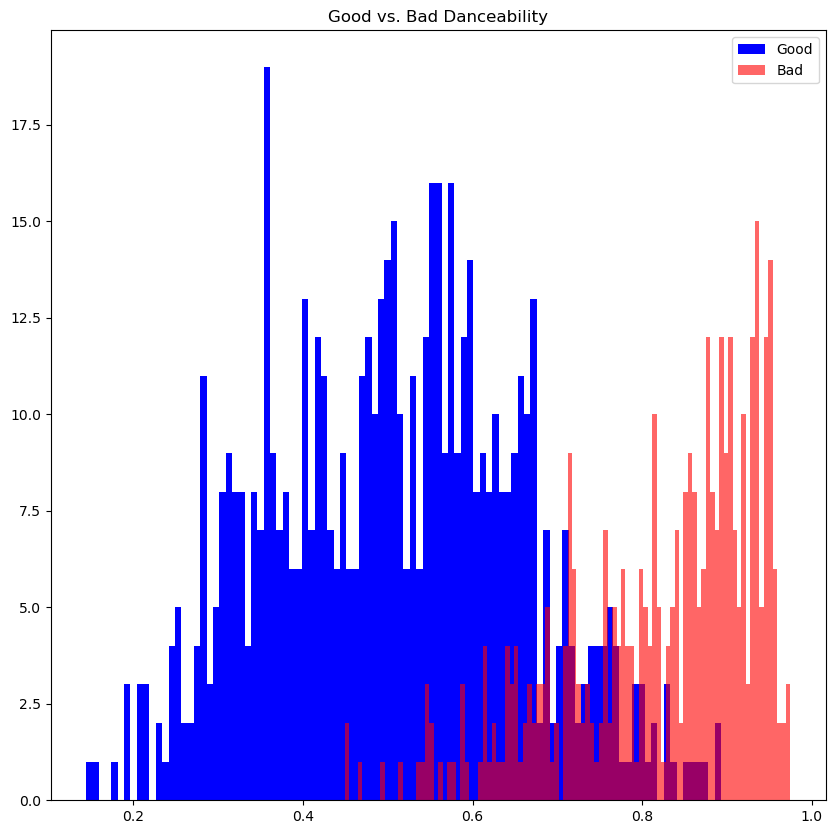

In [222]:
plot_hist_vs('danceability', good_df, bad_df)

In [223]:
X_corr = X_num.corr()
X_corr

,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
popularity,1.000000,-0.384079,0.135429,0.014586,-0.142643,0.022183,-0.337951,-0.218221,0.016007,0.052923,-0.078158,-0.017936,0.221784
danceability,-0.384079,1.000000,-0.218093,-0.008266,0.193557,-0.014678,0.374730,0.249928,-0.110471,-0.241089,0.489170,-0.099241,-0.408175
energy,0.135429,-0.218093,1.000000,0.006208,0.609098,-0.117903,0.003528,-0.615517,0.007416,0.133186,0.175504,0.160046,0.096776
key,0.014586,-0.008266,0.006208,1.000000,-0.020596,-0.120037,-0.027862,0.013634,0.015698,0.026049,0.017479,-0.018611,-0.017536
loudness,-0.142643,0.193557,0.609098,-0.020596,1.000000,-0.121475,0.154052,-0.307631,-0.107871,-0.062752,0.198903,0.106652,-0.126487
mode,0.022183,-0.014678,-0.117903,-0.120037,-0.121475,1.000000,-0.010185,0.080176,0.054520,0.007452,-0.016793,0.030074,-0.081542
speechiness,-0.337951,0.374730,0.003528,-0.027862,0.154052,-0.010185,1.000000,0.146399,-0.082719,-0.022655,0.187530,-0.028750,-0.257205
acousticness,-0.218221,0.249928,-0.615517,0.013634,-0.307631,0.080176,0.146399,1.000000,-0.033673,0.016131,-0.079207,-0.095894,-0.165094
instrumentalness,0.016007,-0.110471,0.007416,0.015698,-0.107871,0.054520,-0.082719,-0.033673,1.000000,-0.011522,-0.068729,0.011353,0.074473
liveness,0.052923,-0.241089,0.133186,0.026049,-0.062752,0.007452,-0.022655,0.016131,-0.011522,1.000000,-0.173025,0.061037,0.166894


In [224]:
mask = (abs(X_corr) > .5) & (abs(X_corr) != 1)
X_corr.where(mask).stack().sort_values(ascending=False)

energy        loudness        0.609098
loudness      energy          0.609098
energy        acousticness   -0.615517
acousticness  energy         -0.615517
dtype: float64

<Axes: >

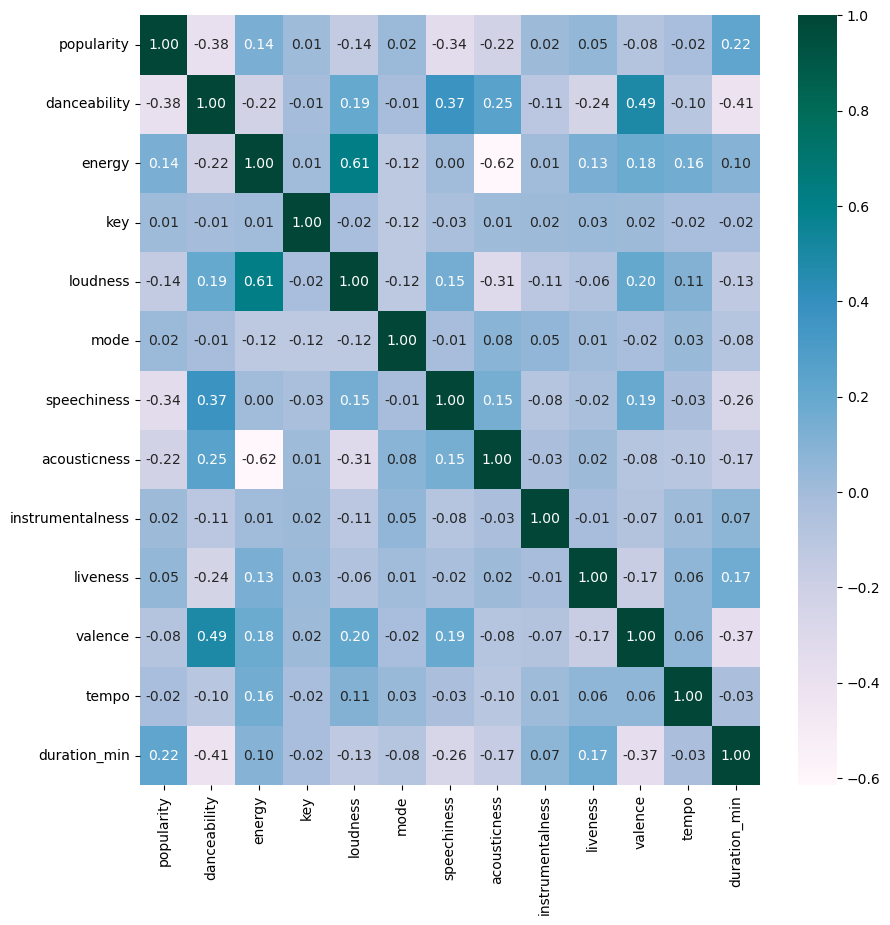

In [225]:
sns.heatmap(X_corr, annot=True, fmt='.2f', cmap='PuBuGn')

## Content-Based Filtering Model

In [320]:
num_user_features, num_item_features = user_df.shape[1], X_num.shape[1]
num_user_features, num_item_features

(13, 13)

In [ ]:
pip install --upgrade tensorflow

In [ ]:
num_outputs = 64
user_NN = tf.keras.models.Sequential([
    tf.keras.layers.Dense(units=256, activation='relu'),
    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dense(units=num_outputs, activation='linear')
])

item_NN = tf.keras.models.Sequential([
    tf.keras.layers.Dense(units=256, activation='relu'),
    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dense(units=num_outputs, activation='linear')
])

input_user = tf.keras.layers.Input(shape=(num_user_features))
vu = user_NN(input_user)
vu = tf.linalg.l2_normalize(vu, axis=1)

input_item = tf.keras.layers.Input(shape=(num_item_features))
vm = item_NN(input_item)
vm = tf.linalg.l2_normalize(vm, axis=1)

output = tf.keras.layers.Dot(axes=1)([vu, vm])

model = tf.keras.Model([input_user, input_item], output)
model.summary()

In [ ]:
opt = tf.keras.optimizers.Adam(learning_rate=1e-5)
cost = tf.keras.losses.MeanSquaredError()
model.compile(loss=cost, optimizer=opt, metrics=['mse'])

In [ ]:
scaler = StandardScaler()

item_norm = scaler.fit_transform()
user_norm = 

In [ ]:
history = model.fit([user_train, item_train], y_train, epochs=100)
history

In [ ]:
model.evaluate([user_train, item_train], y_train)